# Structural Property Comparison — Twitch Networks

Extracts graph attributes (clustering, path length, assortativity, …) from the
already-fitted comparator objects saved by `22-1-twitch-analysis.ipynb` and
builds a summary table suitable for the paper.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, importlib, pickle, gc
sys.path.append('../..')

import numpy as np
import pandas as pd

# Allow unpickling objects saved under the old module path
sys.modules['src.simulation'] = importlib.import_module('src.logit_graph.simulation')

In [2]:
FOLDER_OUTPUT = 'runs/fitted_graphs_comparison_twitch'

# Map pickle filenames to the short labels used in the paper.
# Use the _sample variants for DE/EN/ES/FR (matching Table 2 sigmas)
# and the non-sample variants for RU/PT.
FILE_LABEL_MAP = {
    'comparators_DE_graph_sample.pkl':   'Twitch (DE)',
    'comparators_ENGB_graph_sample.pkl': 'Twitch (EN)',
    'comparators_ES_graph_sample.pkl':   'Twitch (ES)',
    'comparators_FR_graph_sample.pkl':   'Twitch (FR)',
    'comparators_PTBR_graph.pkl':        'Twitch (PT)',
    'comparators_RU_graph.pkl':          'Twitch (RU)',
}

rows = []
for fname, label in FILE_LABEL_MAP.items():
    path = os.path.join(FOLDER_OUTPUT, fname)
    if not os.path.exists(path):
        print(f'MISSING: {path}')
        continue
    with open(path, 'rb') as f:
        comparator = pickle.load(f)
    # Pick the last (most recent) comparator run
    comp = comparator[-1]
    df = comp.summary_df.copy()
    df.insert(0, 'dataset', label)
    rows.append(df)
    del comparator, comp
    gc.collect()

all_df = pd.concat(rows, ignore_index=True)
print(f'{len(all_df)} rows loaded across {len(FILE_LABEL_MAP)} datasets')

36 rows loaded across 6 datasets


In [3]:
# Rename 'Original' → 'Real' for the paper table
all_df['model'] = all_df['model'].replace({'Original': 'Real'})

# Compute average degree from edges & nodes
all_df['avg_degree'] = 2 * all_df['edges'] / all_df['nodes']

# Keep only the columns we need, in order
COLS = ['dataset', 'model', 'avg_degree', 'avg_clustering',
        'avg_path_length', 'diameter', 'assortativity']
table = all_df[COLS].copy()

# Exclude GRG — its parameter search converged to r≈1 producing
# near-complete graphs (density ~0.97), making it meaningless.
table = table[table['model'] != 'GRG'].copy()

# Sort: dataset order, then Real first followed by models alphabetically
dataset_order = ['Twitch (DE)', 'Twitch (EN)', 'Twitch (ES)',
                 'Twitch (FR)', 'Twitch (PT)', 'Twitch (RU)']
model_order = ['Real', 'LG', 'BA', 'WS', 'ER']
table['dataset'] = pd.Categorical(table['dataset'], categories=dataset_order, ordered=True)
table['model']   = pd.Categorical(table['model'],   categories=model_order,   ordered=True)
table = table.sort_values(['dataset', 'model']).reset_index(drop=True)

table

,dataset,model,avg_degree,avg_clustering,avg_path_length,diameter,assortativity
0,Twitch (DE),Real,32.246368,0.200886,2.721571,7,-0.115173
1,Twitch (DE),LG,16.228048,0.001675,3.601888,5,0.002250
2,Twitch (DE),BA,1.999789,0.000000,9.198725,26,-0.069827
3,Twitch (DE),WS,32.000000,0.003266,2.929834,4,-0.013161
4,Twitch (DE),ER,95.155191,0.010030,2.371600,3,-0.001069
5,Twitch (EN),Real,9.914117,0.130928,3.677616,10,-0.121908
6,Twitch (EN),LG,4.974740,0.000913,5.712222,12,-0.005431
7,Twitch (EN),BA,1.999719,0.000000,8.422603,22,-0.069131
8,Twitch (EN),WS,10.000000,0.001213,4.135314,6,-0.033966
9,Twitch (EN),ER,71.378052,0.010055,2.474265,3,0.002247


In [4]:
# Formatted display table
fmt = table.copy()
fmt['avg_degree']      = fmt['avg_degree'].map('{:.2f}'.format)
fmt['avg_clustering']  = fmt['avg_clustering'].map('{:.4f}'.format)
fmt['avg_path_length'] = fmt['avg_path_length'].map('{:.2f}'.format)
fmt['diameter']        = fmt['diameter'].astype(int).astype(str)
fmt['assortativity']   = fmt['assortativity'].map('{:+.4f}'.format)

fmt.columns = ['Dataset', 'Model', r'$\langle k \rangle$', '$C$',
               '$L$', '$D$', '$r$']

display(fmt.style.hide(axis='index'))

Dataset,Model,$\langle k \rangle$,$C$,$L$,$D$,$r$
Twitch (DE),Real,32.25,0.2009,2.72,7,-0.1152
Twitch (DE),LG,16.23,0.0017,3.60,5,+0.0023
Twitch (DE),BA,2.00,0.0000,9.20,26,-0.0698
Twitch (DE),WS,32.00,0.0033,2.93,4,-0.0132
Twitch (DE),ER,95.16,0.0100,2.37,3,-0.0011
Twitch (EN),Real,9.91,0.1309,3.68,10,-0.1219
Twitch (EN),LG,4.97,0.0009,5.71,12,-0.0054
Twitch (EN),BA,2.00,0.0000,8.42,22,-0.0691
Twitch (EN),WS,10.00,0.0012,4.14,6,-0.0340
Twitch (EN),ER,71.38,0.0101,2.47,3,+0.0022


In [5]:
# Generate LaTeX table for the paper
print(r"""\begin{table}[t!]
    \centering
    \caption{Structural properties of real Twitch networks and graphs generated by each fitted model. $\langle k \rangle$ denotes average degree, $C$ the average clustering coefficient, $L$ the average shortest path length, $D$ the diameter, and $r$ the degree assortativity.}
    \label{tab:structural_properties}
    \begin{tabular}{llrrrrr}
        \toprule
        \textbf{Dataset} & \textbf{Model} & \bm{$\langle k \rangle$} & \bm{$C$} & \bm{$L$} & \bm{$D$} & \bm{$r$} \\\\
        \midrule""")

prev_ds = None
for _, row in table.iterrows():
    ds = row['dataset']
    if ds != prev_ds and prev_ds is not None:
        print(r'        \addlinespace')
    prev_ds = ds

    ds_str = ds if ds != prev_ds or prev_ds is None else ''
    # Always print dataset on the Real row, blank for the rest
    show_ds = ds if row['model'] == 'Real' else ''

    print(f"        {show_ds} & {row['model']} "
          f"& {row['avg_degree']:.2f} "
          f"& {row['avg_clustering']:.4f} "
          f"& {row['avg_path_length']:.2f} "
          f"& {int(row['diameter'])} "
          f"& {row['assortativity']:+.4f} \\\\")

print(r"""        \bottomrule
    \end{tabular}
\end{table}""")

\begin{table}[t!]
    \centering
    \caption{Structural properties of real Twitch networks and graphs generated by each fitted model. $\langle k \rangle$ denotes average degree, $C$ the average clustering coefficient, $L$ the average shortest path length, $D$ the diameter, and $r$ the degree assortativity.}
    \label{tab:structural_properties}
    \begin{tabular}{llrrrrr}
        \toprule
        \textbf{Dataset} & \textbf{Model} & \bm{$\langle k \rangle$} & \bm{$C$} & \bm{$L$} & \bm{$D$} & \bm{$r$} \\\\
        \midrule
        Twitch (DE) & Real & 32.25 & 0.2009 & 2.72 & 7 & -0.1152 \\
         & LG & 16.23 & 0.0017 & 3.60 & 5 & +0.0023 \\
         & BA & 2.00 & 0.0000 & 9.20 & 26 & -0.0698 \\
         & WS & 32.00 & 0.0033 & 2.93 & 4 & -0.0132 \\
         & ER & 95.16 & 0.0100 & 2.37 & 3 & -0.0011 \\
        \addlinespace
        Twitch (EN) & Real & 9.91 & 0.1309 & 3.68 & 10 & -0.1219 \\
         & LG & 4.97 & 0.0009 & 5.71 & 12 & -0.0054 \\
         & BA & 2.00 & 0.0000 & 8.42 &

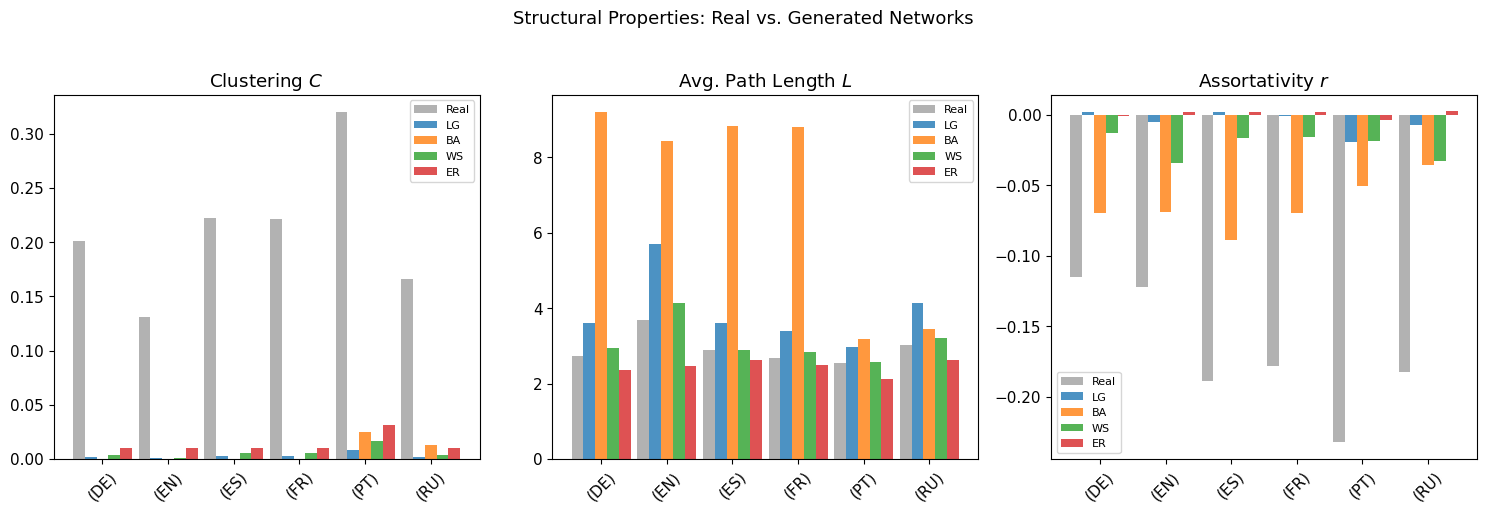

In [6]:
# Quick visual: for each metric, how close is each model to the real network?
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

metrics = ['avg_clustering', 'avg_path_length', 'assortativity']
metric_labels = ['Clustering $C$', 'Avg. Path Length $L$', 'Assortativity $r$']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

datasets = table['dataset'].cat.categories.tolist()
models = [m for m in model_order if m != 'Real']
colors = {'LG': '#1f77b4', 'BA': '#ff7f0e', 'WS': '#2ca02c', 'ER': '#d62728'}

for ax, metric, mlabel in zip(axes, metrics, metric_labels):
    real_vals = table[table['model'] == 'Real'].set_index('dataset')[metric]
    x = np.arange(len(datasets))
    width = 0.18

    # Plot real values as grey bars
    ax.bar(x - 2*width, real_vals.values, width, label='Real', color='grey', alpha=0.6)

    for i, m in enumerate(models):
        model_vals = table[table['model'] == m].set_index('dataset')[metric]
        ax.bar(x + (i-1)*width, model_vals.reindex(datasets).values,
               width, label=m, color=colors[m], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace('Twitch ', '') for d in datasets], rotation=45)
    ax.set_title(mlabel)
    ax.legend(fontsize=8)

fig.suptitle('Structural Properties: Real vs. Generated Networks', y=1.02, fontsize=13)
fig.tight_layout()
plt.savefig('../../images/correction_paper/structural_properties_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()